# Quantum Machine Learning: Clustering with QMeans

### Anirudh Srinivasan | CS20BTECH11059

In [ ]:
!pip install qmeans

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 33.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 23.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 27.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.2/458.2 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 41.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 33.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.3/241.3 kB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 9.2 MB/s e

In [ ]:
!git clone https://github.com/Raijeku/qmeans.git

## KMeans

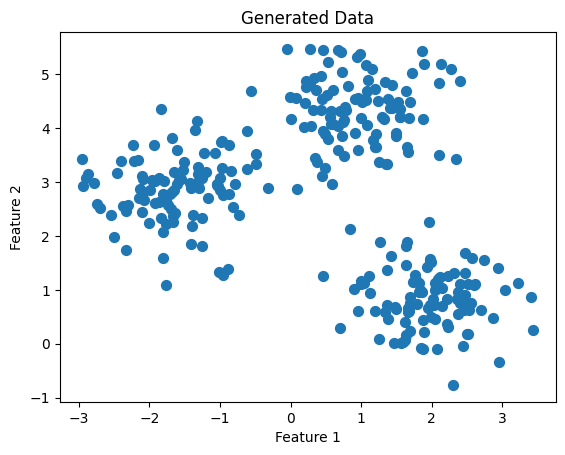

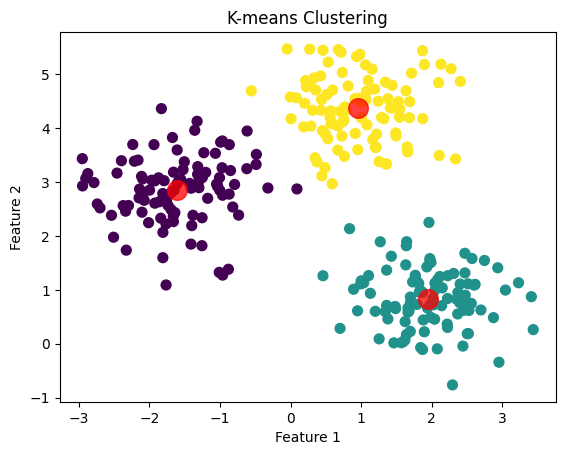

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate synthetic data with 3 clusters
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=0)

# Visualize the data
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Generated Data')
plt.show()

# Apply K-means clustering
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

# Get cluster centers and labels
centers = kmeans.cluster_centers_
labels = kmeans.labels_

# Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-means Clustering')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Silhouette Score
silhouette = silhouette_score(X, labels)

# Calinski-Harabasz Index
calinski_harabasz = calinski_harabasz_score(X, labels)

print("Silhouette Score:", silhouette)
print("Calinski-Harabasz Index:", calinski_harabasz)

Silhouette Score: 0.6596332095691734
Calinski-Harabasz Index: 912.363999941847


## qMeans

In [ ]:
import numpy as np
import pandas as pd
from qmeans.qkmeans import *

backend = Aer.get_backend("aer_simulator_statevector")
qk_means = QuantumKMeans(backend, n_clusters=3, verbose=True)
qk_means.fit(X)

# Get cluster centers and labels
centers = qk_means.cluster_centers_
labels = qk_means.labels_

Data is: [[ 4.28576743e-01  4.97399710e+00]
 [ 1.61990909e+00  6.76452867e-02]
 [ 1.43289271e+00  4.37679234e+00]
 [-1.57846247e+00  3.03445802e+00]
 [-1.65862863e+00  2.26746029e+00]
 [-1.52172727e+00  3.23408479e+00]
 [ 8.36856841e-01  2.13635938e+00]
 [ 2.41008767e-01  4.81040511e+00]
 [-2.10320664e+00  2.44201184e+00]
 [-4.83580407e-01  3.51451890e+00]
 [ 8.93499638e-01  1.01093082e+00]
 [ 2.39564169e+00  7.64058600e-01]
 [ 3.04414848e+00  9.96200313e-01]
 [ 1.24258802e+00  4.50399192e+00]
 [ 1.89462740e+00  2.20856861e-01]
 [-1.65707376e+00  3.18511821e+00]
 [ 1.21767506e+00  3.89290127e+00]
 [ 1.20212540e+00  3.64414685e+00]
 [-1.32356154e+00  4.13050840e+00]
 [ 1.34195197e+00  5.93573847e-01]
 [-1.79041773e+00  3.02668532e+00]
 [ 1.16411070e+00  3.79132988e+00]
 [ 1.36085437e+00  7.10288309e-01]
 [ 4.38990142e-01  4.53592883e+00]
 [-2.53563494e+00  2.38449945e+00]
 [-2.08499791e+00  2.81072881e+00]
 [ 3.47138300e-01  3.45177657e+00]
 [-2.14486518e+00  2.70791624e+00]
 [ 2.402380

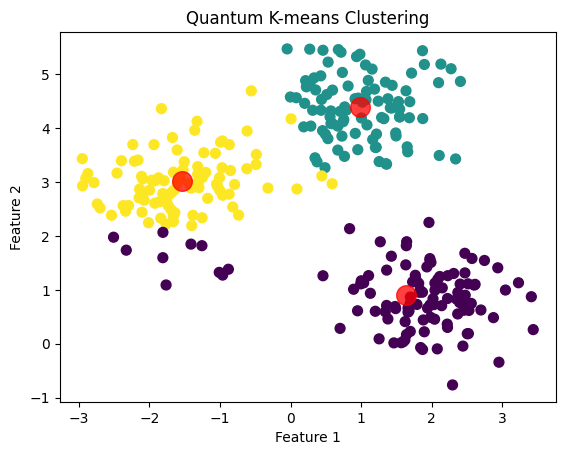

In [ ]:
import matplotlib.pyplot as plt

# Convert DataFrame to NumPy array
centers_array = centers.values

# Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centers_array[:, 0], centers_array[:, 1], c='red', s=200, alpha=0.75)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Quantum K-means Clustering')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Silhouette Score
silhouette = silhouette_score(X, labels)

# Calinski-Harabasz Index
calinski_harabasz = calinski_harabasz_score(X, labels)

print("Silhouette Score:", silhouette)
print("Calinski-Harabasz Index:", calinski_harabasz)

Silhouette Score: 0.5964193344956144
Calinski-Harabasz Index: 550.0316021279036


## Inference

1. **K Means:**
   - Silhouette Score: 0.6596
   - Calinski-Harabasz Index: 912.364

2. **Quantum K Means:**
   - Silhouette Score: 0.5964
   - Calinski-Harabasz Index: 550.032

Based on these metrics:

- **Silhouette Score:** Measures how similar an object is to its own cluster compared to other clusters. Higher values indicate dense, well-separated clusters. In this case, K Means has a higher silhouette score, suggesting better-defined clusters.
  
- **Calinski-Harabasz Index:** Also known as the Variance Ratio Criterion, it evaluates the ratio of between-cluster dispersion to within-cluster dispersion. Higher values indicate denser and more well-separated clusters. K Means again has a higher index, indicating better-defined clusters.



## Spherical KMeans

### Same Dataset

In [ ]:
import numpy as np

class SphericalKMeans:
    def __init__(self, n_clusters, max_iter=100, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.centers = None

    def fit(self, X):
        rng = np.random.default_rng(self.random_state)
        indices = rng.choice(X.shape[0], size=self.n_clusters, replace=False)
        self.centers = X[indices]

        for _ in range(self.max_iter):
            distances = 1 - X @ self.centers.T  # Cosine distance
            labels = np.argmin(distances, axis=1)

            new_centers = []
            for k in range(self.n_clusters):
                cluster_points = X[labels == k]
                if len(cluster_points) > 0:
                    new_centers.append(cluster_points.mean(axis=0))
                else:
                    # If the cluster is empty, keep the previous center
                    new_centers.append(self.centers[k])

            new_centers = np.array(new_centers)

            if np.allclose(self.centers, new_centers):
                break

            self.centers = new_centers

    def predict(self, X):
        distances = 1 - X @ self.centers.T  # Cosine distance
        return np.argmin(distances, axis=1)

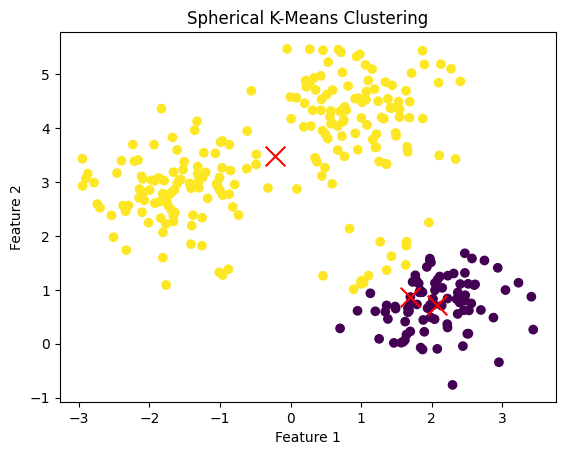

In [ ]:
# Create and fit the spherical k-means model
spherical_kmeans = SphericalKMeans(n_clusters=3, max_iter=100, random_state=42)
spherical_kmeans.fit(X)

# Predict cluster labels for each data point
labels = spherical_kmeans.predict(X)

# Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(spherical_kmeans.centers[:, 0], spherical_kmeans.centers[:, 1], c='red', marker='x', s=200)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Spherical K-Means Clustering')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Silhouette Score
silhouette = silhouette_score(X, labels)

# Calinski-Harabasz Index
calinski_harabasz = calinski_harabasz_score(X, labels)

print("Silhouette Score:", silhouette)
print("Calinski-Harabasz Index:", calinski_harabasz)

Silhouette Score: 0.5072594373151806
Calinski-Harabasz Index: 322.74412061182613


### Other Dataset

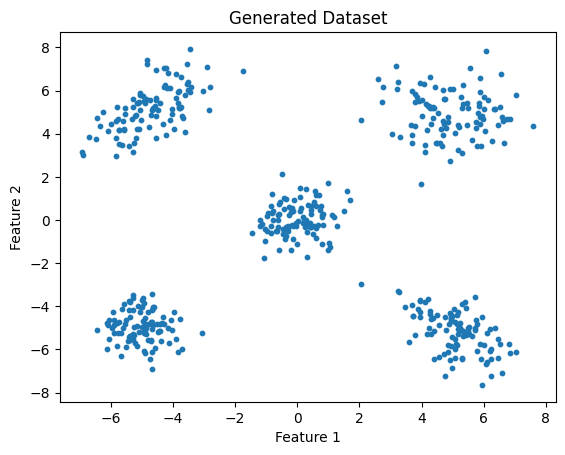

In [ ]:
# Number of clusters
num_clusters = 5

# Mean vectors for each cluster
means = np.array([[0, 0],
                  [5, 5],
                  [-5, 5],
                  [5, -5],
                  [-5, -5]])

# Covariance matrices for each cluster (varying sizes and shapes)
covs = [np.array([[0.5, 0.1],
                  [0.1, 0.5]]),
        np.array([[1, 0],
                  [0, 1]]),
        np.array([[1, 0.5],
                  [0.5, 1]]),
        np.array([[1, -0.5],
                  [-0.5, 1]]),
        np.array([[0.5, 0],
                  [0, 0.5]])]

# Number of points in each cluster
num_points_per_cluster = 100

# Generate data points
data = np.zeros((num_clusters * num_points_per_cluster, 2))
for i in range(num_clusters):
    start_idx = i * num_points_per_cluster
    end_idx = (i + 1) * num_points_per_cluster
    data[start_idx:end_idx, :] = np.random.multivariate_normal(means[i], covs[i], num_points_per_cluster)

# Shuffle the data
np.random.shuffle(data)

# Plot the generated dataset
plt.scatter(data[:, 0], data[:, 1], s=10)
plt.title('Generated Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## Spherical KMeans

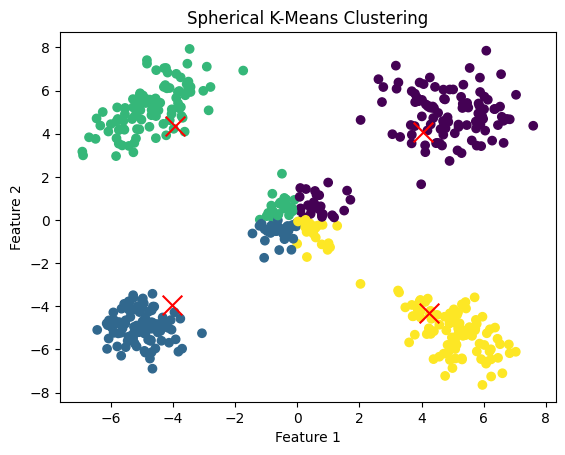

In [ ]:
# Create and fit the spherical k-means model
spherical_kmeans = SphericalKMeans(n_clusters=4, max_iter=100, random_state=42)
spherical_kmeans.fit(data)

# Predict cluster labels for each data point
labels = spherical_kmeans.predict(data)

# Visualize the clusters
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis')
plt.scatter(spherical_kmeans.centers[:, 0], spherical_kmeans.centers[:, 1], c='red', marker='x', s=200)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Spherical K-Means Clustering')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Silhouette Score
silhouette = silhouette_score(data, labels)

# Calinski-Harabasz Index
calinski_harabasz = calinski_harabasz_score(data, labels)

print("Silhouette Score:", silhouette)
print("Calinski-Harabasz Index:", calinski_harabasz)

Silhouette Score: 0.582017849376397
Calinski-Harabasz Index: 726.1552259399316


## KMeans

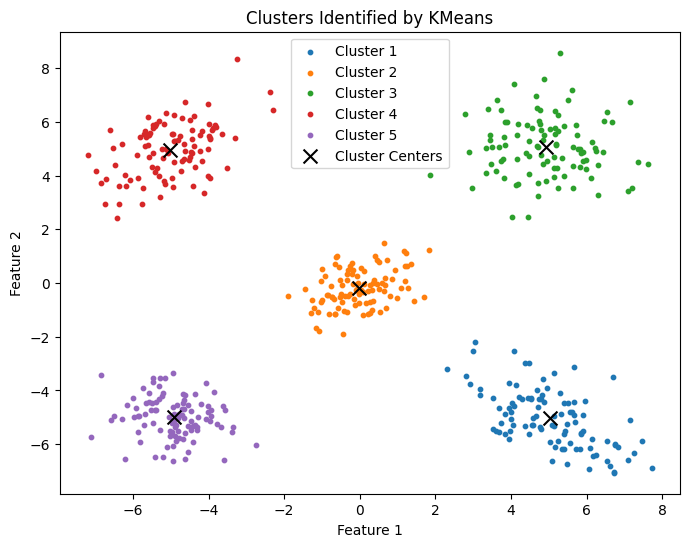

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Fit KMeans on the generated dataset
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(data)

# Get cluster centers and labels
centers = kmeans.cluster_centers_
labels = kmeans.labels_

# Visualize the clusters
plt.figure(figsize=(8, 6))
for i in range(5):
    cluster_points = data[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i+1}', s=10)

plt.scatter(centers[:, 0], centers[:, 1], color='black', marker='x', label='Cluster Centers', s=100)
plt.title('Clusters Identified by KMeans')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Silhouette Score
silhouette = silhouette_score(data, labels)

# Calinski-Harabasz Index
calinski_harabasz = calinski_harabasz_score(data, labels)

print("Silhouette Score:", silhouette)
print("Calinski-Harabasz Index:", calinski_harabasz)

Silhouette Score: 0.7574417662251205
Calinski-Harabasz Index: 2722.3076818672052


## Quantum Spherical KMeans

In [ ]:
import numpy as np
import pandas as pd
from qmeans.qkmeans import *

backend = Aer.get_backend("aer_simulator_statevector")
qk_means = QuantumKMeans(backend, n_clusters=5, map_type = 'angle',verbose=True)
qk_means.fit(data)

# Get cluster centers and labels
centers = qk_means.cluster_centers_
labels = qk_means.labels_

Data is: [[ 3.78369137e+00 -5.31469692e+00]
 [ 1.12306966e+00  2.19948904e-01]
 [-9.62102344e-02  9.32653204e-01]
 [-6.06137104e-01  2.79557083e-01]
 [-5.74475905e+00  4.17328092e+00]
 [ 5.15295257e+00 -4.82713207e+00]
 [ 3.93660207e+00 -3.77182186e+00]
 [ 4.79723811e+00 -5.11269640e+00]
 [ 1.79623214e-01 -1.51475821e-01]
 [ 4.94344442e+00 -5.82419460e+00]
 [-1.20879492e+00  1.66476324e-02]
 [ 6.36714561e+00  5.14691120e+00]
 [ 6.44688604e+00 -5.50353237e+00]
 [ 7.85592103e-01 -1.12819199e+00]
 [ 5.29896543e+00 -6.40962461e+00]
 [ 4.20025886e+00 -3.64256404e+00]
 [-4.11317264e+00  6.11757999e+00]
 [-5.68139461e+00 -5.22722245e+00]
 [ 4.70095526e+00  3.95171330e+00]
 [-4.64718611e+00 -4.01136786e+00]
 [-5.13621423e+00  5.44011425e+00]
 [ 6.66909523e-01 -2.53521522e-01]
 [-4.47286363e-01 -6.59748344e-01]
 [-4.94332276e+00 -4.90259583e+00]
 [ 4.19274363e-01 -3.40496239e-01]
 [ 4.38584416e+00 -6.44589273e+00]
 [-5.66194143e+00 -4.10980832e+00]
 [-4.98158448e+00 -4.69393161e+00]
 [-4.123874

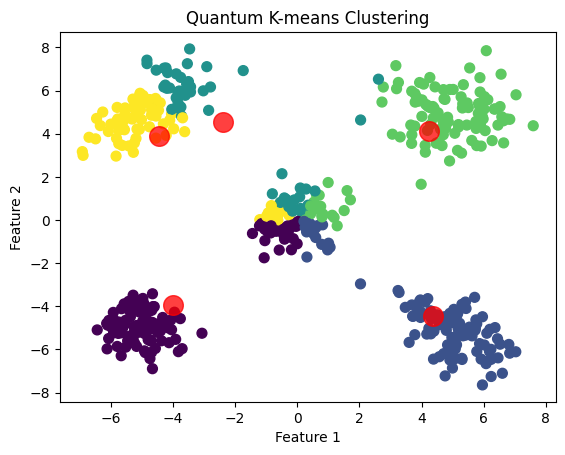

In [ ]:
import matplotlib.pyplot as plt

# Convert DataFrame to NumPy array
centers_array = centers.values

# Visualize the clusters
plt.scatter(data[:, 0], data[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centers_array[:, 0], centers_array[:, 1], c='red', s=200, alpha=0.75)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Quantum K-means Clustering')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Silhouette Score
silhouette = silhouette_score(data, labels)

# Calinski-Harabasz Index
calinski_harabasz = calinski_harabasz_score(data, labels)

print("Silhouette Score:", silhouette)
print("Calinski-Harabasz Index:", calinski_harabasz)

Silhouette Score: 0.1806126387506583
Calinski-Harabasz Index: 225.9886957865548
